In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from category_encoders import BinaryEncoder
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Optional tools
# from user_agents import parse
# from ip2geotools.databases.noncommercial import DbIpCity as ip2geo
# from geopy.geocoders import Nominatim
# from geopy.distance import great_circle

sns.set(style='whitegrid')

In [5]:
df=pd.read_csv('emails.csv')
df

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


In [44]:
from sklearn.model_selection import train_test_split
X=df['text']
y=df['spam']
X_train, X_test, y_train, y_test=train_test_split(X,y,random_state=42,test_size=0.2,shuffle=True,stratify=y)

In [45]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4582,), (1146,), (4582,), (1146,))

In [46]:
victorize=TfidfVectorizer()
X_train_vec=victorize.fit_transform(X_train)
X_test_vec=victorize.transform(X_test)

In [47]:
from sklearn.neighbors import KNeighborsClassifier

In [48]:
model=KNeighborsClassifier(n_neighbors=3,metric='cosine')

In [50]:
model.fit(X_train_vec,y_train)

KNeighborsClassifier(metric='cosine', n_neighbors=3)

In [73]:
from sklearn.metrics import accuracy_score

In [74]:
y_pred = model.predict(X_test_vec)

In [75]:
print(f"accuracy :",accuracy_score(y_test,y_pred))

accuracy : 0.9781849912739965


In [77]:
from sklearn.model_selection import cross_val_score

print(f"accuracy :",accuracy_score(y_test,y_pred))
valid_acc=cross_val_score(model,X_train_vec,y_train,cv=5)
pd.DataFrame(valid_acc).describe()


accuracy : 0.9781849912739965


,0
count,5.000000
mean,0.973156
std,0.007463
min,0.964013
25%,0.970524
50%,0.970524
75%,0.977074
max,0.983642


In [59]:
# valid_pred
from sklearn.model_selection import cross_val_predict

y_valid_pred = cross_val_predict(model, X_train_vec, y_train, cv=5, method='predict')
y_train.shape, y_valid_pred.shape

((4582,), (4582,))

In [63]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(f"Validation Precision: {precision_score(y_train, y_valid_pred)}")
print(f"Validation recall: {recall_score(y_train, y_valid_pred)}")
print(f"Validation f1: {f1_score(y_train, y_valid_pred)}")

Validation Precision: 0.936993699369937
Validation recall: 0.9515539305301646
Validation f1: 0.9442176870748299


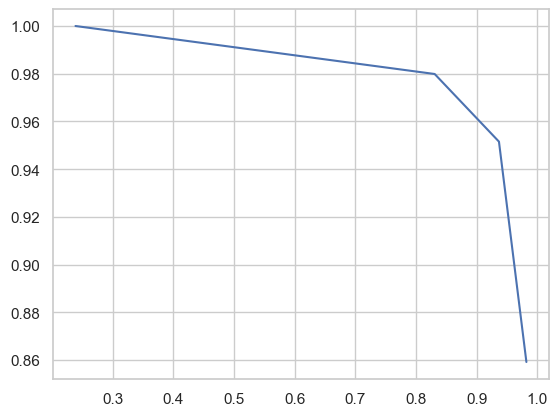

In [70]:
# PR Curve
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
y_valid_proba = cross_val_predict(model, X_train_vec, y_train, cv=5, method='predict_proba')
y_log_valid_scores = y_valid_proba[:, 1]

precision_log_scores, recall_log_scores, thresholds_log = precision_recall_curve(y_train, y_log_valid_scores)
plt.plot(precision_log_scores[:-1], recall_log_scores[:-1], label='PR Curve knn')

In [61]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train, y_valid_pred)

array([[3418,   70],
       [  53, 1041]])

In [103]:
import numpy as np
indx_p_90 = np.argmax(recall_log_scores <= 0.90)
threshold_90_recall = thresholds_log[indx_p_90]
threshold_90_recall

np.float64(1.0)

In [110]:
y_log_valid_pred_threshold = (y_log_valid_scores >= 0.777)

print(f"Valid Precision: {precision_score(y_train, y_log_valid_pred_threshold)}")
print(f"Valid recall: {recall_score(y_train, y_log_valid_pred_threshold)}")
print(f"Valid f1: {f1_score(y_train, y_log_valid_pred_threshold)}")
confusion_matrix(y_train, y_log_valid_pred_threshold)

Valid Precision: 0.9822361546499477
Valid recall: 0.8592321755027422
Valid f1: 0.916626036079961


array([[3471,   17],
       [ 154,  940]])

In [54]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[856,  16],
       [  9, 265]])

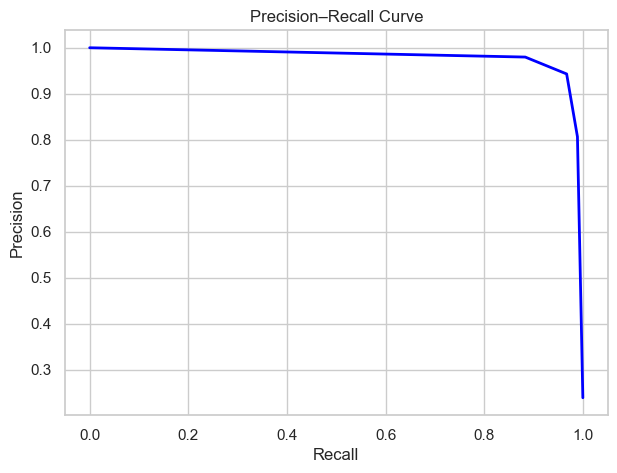

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

y_scores = model.predict_proba(X_test_vec)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores, pos_label=1)
plt.figure(figsize=(7,5))
plt.plot(recall, precision, color='blue', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.grid(True)
plt.show()


In [113]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report

threshold = 0.777
y_scores_test = model.predict_proba(X_test_vec)[:, 1]
y_pred_custom = (y_scores_test >= threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_custom)
prec = precision_score(y_test, y_pred_custom)
rec = recall_score(y_test, y_pred_custom)
f1 = f1_score(y_test, y_pred_custom)
print(f"Custom threshold = {threshold}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nConfusion Matrix:\n", cm)



Custom threshold = 0.777
Precision: 0.9798
Recall:    0.8832
F1-score:  0.9290

Confusion Matrix:
 [[867   5]
 [ 32 242]]


In [ ]:
y_score = model.predict_proba(X_test_vec[0])[:, 1][0]
y_score

np.float64(1.0)

In [127]:
true_label = y_test.iloc[0]
true_label

np.int64(1)